In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 192, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 192 (delta 16), reused 9 (delta 9), pack-reused 159 (from 1)
Receiving objects: 100% (192/192), 5.23 MiB | 22.87 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [3]:
# local files
from src import utils
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet
from src.bbbc038_dataset import BBBC038Dataset

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:

# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar

if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train
    !rm ./data/stage1_train.zip

if not os.path.exists('./data/stage1_test'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip -P ./data
    !cd data && unzip -q stage1_test.zip -d stage1_test
    !rm ./data/stage1_test.zip

--2026-09-11 19:11:32--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  12.0MB/s    in 8.1s    

2026-09-11 19:11:41 (9.72 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]

--2026-09-11 19:11:44--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9545388 (9.1M) [application/zip]
Saving to: ‘./data/stage1_test.zip’

stage1_test.zip     100%[===================>]   9.10M  4.84

In [37]:
# carrega o dataset

dataset = BBBC038Dataset(
    is_training=True,
    path="data/stage1_train",
    img_size=128
)

split_generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [0.7, 0.15, 0.15],
    generator=split_generator
)


In [49]:
# Treinando a ResUNet no BBBC038

model = ResUNet(3, 1).to(device)

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()

for epoch in range(10):
    for batch, (image_id, X, y, instance_map) in enumerate(loader):
        X = X.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()

        if batch % 5 == 0:
            print(f"{epoch}/{batch} - loss={loss.item():.6f}")

0/0 - loss=0.856298
0/5 - loss=0.719768
0/10 - loss=0.667450
0/15 - loss=0.560130
0/20 - loss=0.515464
0/25 - loss=0.517792
1/0 - loss=0.417717
1/5 - loss=0.372434
1/10 - loss=0.344688
1/15 - loss=0.356799
1/20 - loss=0.298697
1/25 - loss=0.223850
2/0 - loss=0.233244
2/5 - loss=0.259530
2/10 - loss=0.210179
2/15 - loss=0.317062
2/20 - loss=0.226667
2/25 - loss=0.201623
3/0 - loss=0.179765
3/5 - loss=0.203106
3/10 - loss=0.171388
3/15 - loss=0.164350
3/20 - loss=0.169111
3/25 - loss=0.167204
4/0 - loss=0.130074
4/5 - loss=0.218808
4/10 - loss=0.189428
4/15 - loss=0.167792
4/20 - loss=0.145370
4/25 - loss=0.148716
5/0 - loss=0.119442
5/5 - loss=0.233718
5/10 - loss=0.178891
5/15 - loss=0.116935
5/20 - loss=0.115520
5/25 - loss=0.239134
6/0 - loss=0.180545
6/5 - loss=0.160365
6/10 - loss=0.152149
6/15 - loss=0.170855
6/20 - loss=0.180710
6/25 - loss=0.125973
7/0 - loss=0.118877
7/5 - loss=0.143799
7/10 - loss=0.172874
7/15 - loss=0.148906
7/20 - loss=0.167770
7/25 - loss=0.164326
8/0 - lo

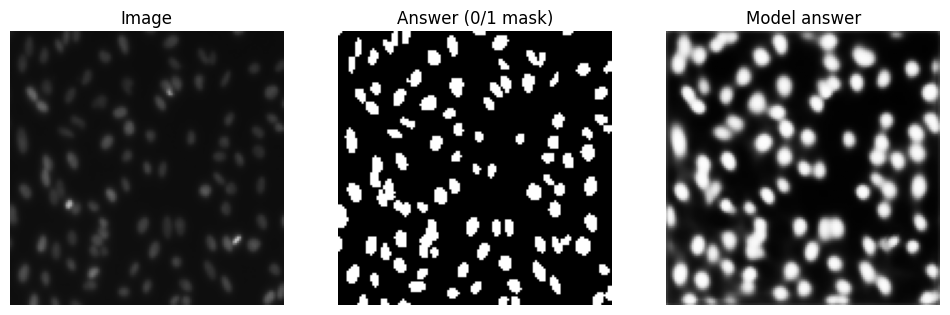

In [51]:
# Verificando a saída do modelo

model.eval()

with torch.no_grad():
    for image_id, img, mask, instance_map in DataLoader(test_dataset, shuffle=True):
        probability = torch.sigmoid(model(img.to(device)))[0, 0].cpu().numpy()

        img_np = img[0].permute(1, 2, 0).numpy()
        mask_np = mask[0].numpy()

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(img_np)
        axes[0].set_title("Image")

        axes[1].imshow(mask_np, cmap="gray")
        axes[1].set_title("Answer (0/1 mask)")

        axes[2].imshow(probability, cmap="gray", vmin=0, vmax=1)
        axes[2].set_title("Model answer")

        for ax in axes:
            ax.axis("off")

        plt.show()
        break


Melhor threshold na validação: 0.50
IoU de validação no threshold escolhido: 0.7330
Dice de validação no threshold escolhido: 0.8374


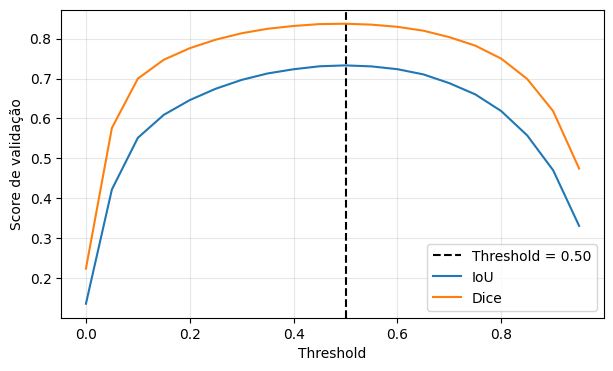

IoU final: 0.7048245072364807
Dice final: 0.8147839307785034


In [54]:

# computa o IoU e Dice no conjunto de validação/teste
model.eval()

def pred(x):
    return torch.sigmoid(model(x.to(device)))[0].cpu()

thresholds = torch.arange(0, 1, .05)

with torch.no_grad():

    iou_scores = []
    dice_scores = []

    for _, x, y, _ in DataLoader(  val_dataset, batch_size=1, shuffle=False, pin_memory=True):

        y_hat = pred(x)

        iou_scores.append([float(utils.iou_score(1 * (y_hat > threshold), y)) for threshold in thresholds])

        dice_scores.append([float(utils.dice_score(1 * (y_hat > threshold), y)) for threshold in thresholds])

    iou_scores = torch.tensor(iou_scores, dtype=torch.float32).mean(dim=0)

    dice_scores = torch.tensor(dice_scores, dtype=torch.float32).mean(dim=0)

    best_index = int(iou_scores.argmax())
    best_threshold = float(thresholds[best_index])

    print(
        f"Melhor threshold na validação: "
        f"{best_threshold:.2f}"
    )

    print(
        f"IoU de validação no threshold escolhido: "
        f"{iou_scores[best_index]:.4f}"
    )

    print(
        f"Dice de validação no threshold escolhido: "
        f"{dice_scores[best_index]:.4f}"
    )

    # Curvas de validação
    plt.figure(figsize=(7, 4))

    plt.axvline(best_threshold, color="black", linestyle="--", label=f"Threshold = {best_threshold:.2f}")
    plt.plot(thresholds, iou_scores, label="IoU")
    plt.plot(thresholds, dice_scores, label="Dice" )

    plt.xlabel("Threshold")
    plt.ylabel("Score de validação")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Computa IoU e Dice no conjunto de teste
    iou_scores_test = []
    dice_scores_test = []

    for _, x, y, _ in DataLoader(test_dataset, batch_size=1, shuffle=False, pin_memory=True):

        y_hat = pred(x)

        binary_prediction = (1 * (y_hat > best_threshold))

        iou_scores_test.append(float(utils.iou_score(binary_prediction, y)))

        dice_scores_test.append(float(utils.dice_score(binary_prediction, y)))

    final_iou_score = torch.tensor(iou_scores_test).mean().item()

    final_dice_score = torch.tensor(dice_scores_test).mean().item()

    print("IoU final:", final_iou_score)
    print("Dice final:", final_dice_score)

ID: 37ed50eea5a1e0bade3e6753793b6caeb061cd4c2f365658c257f69cab1f6288
Número de instâncias GT: 38
Número de instâncias previstas: 25


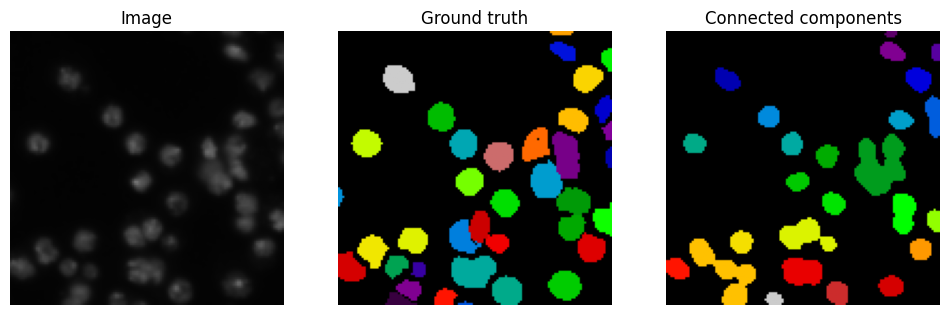

In [55]:
image_id, image, semantic_mask, gt_instance_map = next(
    iter(DataLoader(test_dataset, batch_size=1, shuffle=False))
)

model.eval()
with torch.no_grad():
    probability = torch.sigmoid(model(image.to(device)))[0, 0].cpu().numpy()

pred_instance_map = utils.probability_to_instances(probability,threshold=best_threshold)

gt_map = gt_instance_map[0].numpy()
pred_map = pred_instance_map

print("ID:", image_id[0])
print("Número de instâncias GT:", len(np.unique(gt_map)) - 1)
print("Número de instâncias previstas:", len(np.unique(pred_map)) - 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image[0].permute(1, 2, 0))
axes[0].set_title("Image")
axes[1].imshow(gt_map, cmap="nipy_spectral")
axes[1].set_title("Ground truth")
axes[2].imshow(pred_map, cmap="nipy_spectral")
axes[2].set_title("Connected components")
for ax in axes:
    ax.axis("off")
plt.show()


In [56]:
import pandas as pd

per_threshold_rows = []
per_image_rows = []

model.eval()

with torch.no_grad():
    for image_id, image, semantic_mask, gt_batch in DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False
    ):
        probability = torch.sigmoid( model(image.to(device)))[0, 0].cpu().numpy()

        pred_map = utils.probability_to_instances(probability,threshold=best_threshold)

        gt_map = gt_batch[0].numpy()

        threshold_results = utils.evaluate_instance_prediction(gt_map, pred_map)

        n_gt = len(utils.get_instance_ids(gt_map))
        n_pred = len(utils.get_instance_ids(pred_map))

        image_map = np.mean([result["AP"] for result in threshold_results])

        per_image_rows.append({
            "image_id": image_id[0],
            "n_gt": n_gt,
            "n_pred": n_pred,
            "count_absolute_error": abs(n_pred - n_gt),
            "mAP": image_map
        })

        for result in threshold_results:
            per_threshold_rows.append({"image_id": image_id[0], **result})

per_image_df = pd.DataFrame(per_image_rows)
per_threshold_df = pd.DataFrame(per_threshold_rows)


In [46]:
ap_by_threshold = (
    per_threshold_df
    .groupby("iou_threshold", as_index=False)["AP"]
    .mean()
)

final_map = per_image_df["mAP"].mean()
count_mae = per_image_df["count_absolute_error"].mean()

display(ap_by_threshold)

print(f"mAP@[0.50:0.05:0.95]: {final_map:.4f}")
print(f"Erro absoluto médio de contagem: {count_mae:.4f} objetos/imagem")


,iou_threshold,AP
0,0.50,0.326415
1,0.55,0.292531
2,0.60,0.265998
3,0.65,0.229234
4,0.70,0.180704
5,0.75,0.129868
6,0.80,0.086500
7,0.85,0.042976
8,0.90,0.012694
9,0.95,0.001347


mAP@[0.50:0.05:0.95]: 0.1568
Erro absoluto médio de contagem: 27.2000 objetos/imagem


In [47]:
# Erro absoluto de contagem por imagem
count_report = per_image_df[[
    "image_id",
    "n_gt",
    "n_pred",
    "count_absolute_error"
]]

display(count_report)


,image_id,n_gt,n_pred,count_absolute_error
0,37ed50eea5a1e0bade3e6753793b6caeb061cd4c2f3656...,38,25,13
1,0ddd8deaf1696db68b00c600601c6a74a0502caaf27422...,32,23,9
2,a6515d73077866808ad4cb837ecdac33612527b8a1041e...,15,15,0
3,fa751ff3a6332c95cb5cb1d28563553914295e9e7d35c4...,43,35,8
4,6af82abb29539000be4696884fc822d3cafcb2105906dc...,45,33,12
...,...,...,...,...
95,93cfd412c7de5210bbd262ec3a602cfea65072e9272e9f...,6,6,0
96,f7e5dcfc9c93183c668c5a4ab028d5faad54fb54298711...,26,24,2
97,1a75e9f15481d11084fe66bc2a5afac6dc5bec20ed56a7...,8,13,5
98,0d3640c1f1b80f24e94cc9a5f3e1d9e8db7bf6af7d4aba...,21,14,7


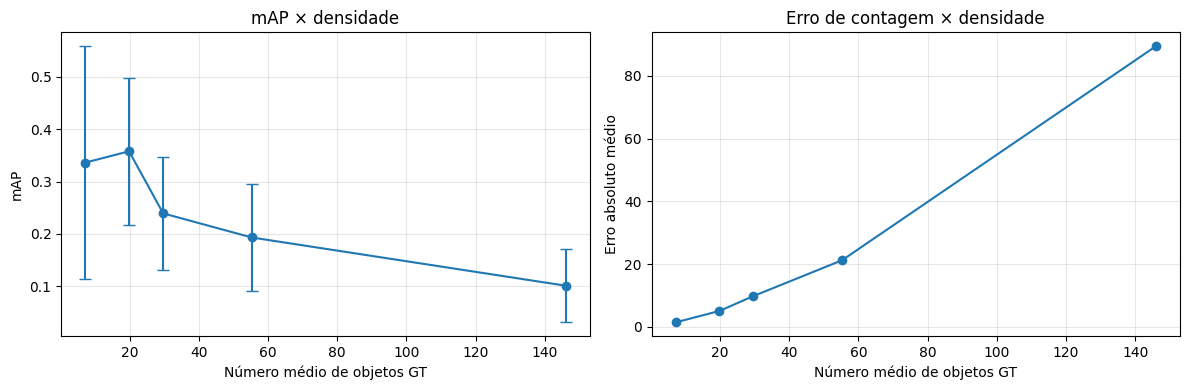

,density_group,mean_n_gt,mean_mAP,std_mAP,mean_count_error,n_images
0,"(0.999, 14.8]",7.20,0.336114,0.222440,1.45,20
1,"(14.8, 24.6]",19.85,0.357735,0.140717,5.10,20
2,"(24.6, 37.4]",29.70,0.239144,0.107483,9.85,20
3,"(37.4, 73.2]",55.30,0.193103,0.102101,21.25,20
4,"(73.2, 368.0]",146.00,0.101025,0.070136,89.45,20


In [57]:
n_bins = min(5, per_image_df["n_gt"].nunique())

if n_bins >= 2:
    density_data = per_image_df.copy()
    density_data["density_group"] = pd.qcut(
        density_data["n_gt"],
        q=n_bins,
        duplicates="drop"
    )

    density_summary = (
        density_data
        .groupby("density_group", observed=True)
        .agg(
            mean_n_gt=("n_gt", "mean"),
            mean_mAP=("mAP", "mean"),
            std_mAP=("mAP", "std"),
            mean_count_error=("count_absolute_error", "mean"),
            n_images=("image_id", "size")
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].errorbar(
        density_summary["mean_n_gt"],
        density_summary["mean_mAP"],
        yerr=density_summary["std_mAP"].fillna(0),
        marker="o",
        capsize=4
    )
    axes[0].set_xlabel("Número médio de objetos GT")
    axes[0].set_ylabel("mAP")
    axes[0].set_title("mAP × densidade")
    axes[0].grid(alpha=0.3)

    axes[1].plot(
        density_summary["mean_n_gt"],
        density_summary["mean_count_error"],
        marker="o"
    )
    axes[1].set_xlabel("Número médio de objetos GT")
    axes[1].set_ylabel("Erro absoluto médio")
    axes[1].set_title("Erro de contagem × densidade")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(density_summary)
else:
    print("Não há densidades distintas suficientes para formar grupos.")
